In [1]:
import matplotlib.pyplot as plt
from ase.build import graphene
from ase.io import write
import ase
import abtem

(examples:stem_quickstart)=
# STEM quickstart

This notebook demonstrates a basic simulation of a scanning transmission electron microscopy image of graphene with a silicon dopant.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [2]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model
We create an orthogonal graphene cell. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

In [3]:
#atoms = abtem.orthogonalize_cell(graphene(vacuum=2))
cif = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/Irradiation_Al2Cu/Al2Cu.cif"
atoms = ase.io.read(cif)
atoms = atoms * (2, 2, 2)

We dope the graphene with silicon by changing the atomic number of one of the atoms.

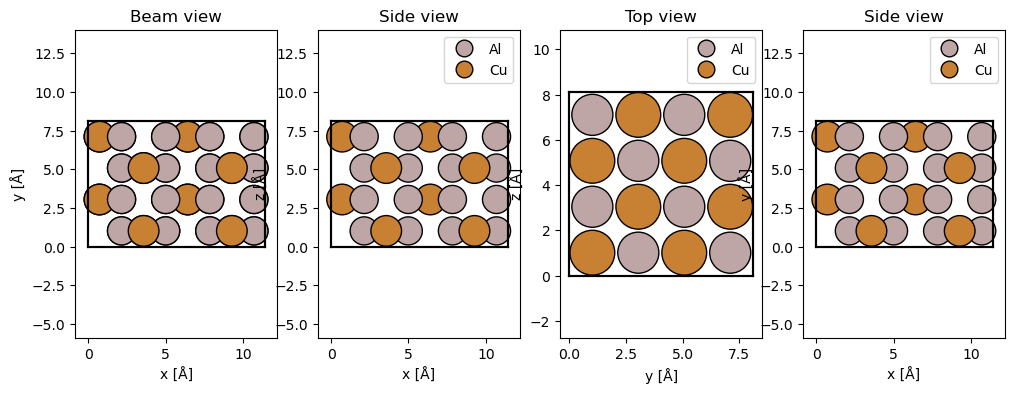

In [4]:
#atoms.numbers[17] = 14
desired_rotation = 90
rotate_atoms = atoms.copy()
rotate_atoms.rotate(desired_rotation, "x", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 4))
abtem.show_atoms(rotate_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(rotate_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax3, plane="yz", title="Top view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax4, plane="xy", title="Side view", legend=True);

In [5]:
atoms = rotate_atoms

## Potential

We create an ensemble of potentials using the frozen phonon model. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [6]:
frozen_phonons = abtem.FrozenPhonons(atoms, 8, sigmas=0.1)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [7]:
potential = abtem.Potential(frozen_phonons, sampling=0.05)

## Wave function

We create a probe wave function at an energy of $80 \ \mathrm{keV}$, an objective aperture of $30 \ \mathrm{mrad}$, a spherical aberration of $10 \ \mu\mathrm{m}$ and Scherzer defocus. See our [walkthrough on wave functions](walkthrough:wave_functions).

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence). 

In [8]:
probe = abtem.Probe(energy=300e3, semiangle_cutoff=25, Cs=10e4, defocus="scherzer")
probe.grid.match(potential)

print(f"defocus = {probe.aberrations.defocus} Å")
print(f"FWHM = {probe.profiles().width().compute()} Å")

defocus = 54.3426474756167 Å
FWHM = 0.39840614795684814 Å


We show the profile of the probe.

[########################################] | 100% Completed | 101.16 ms
[########################################] | 100% Completed | 100.97 ms


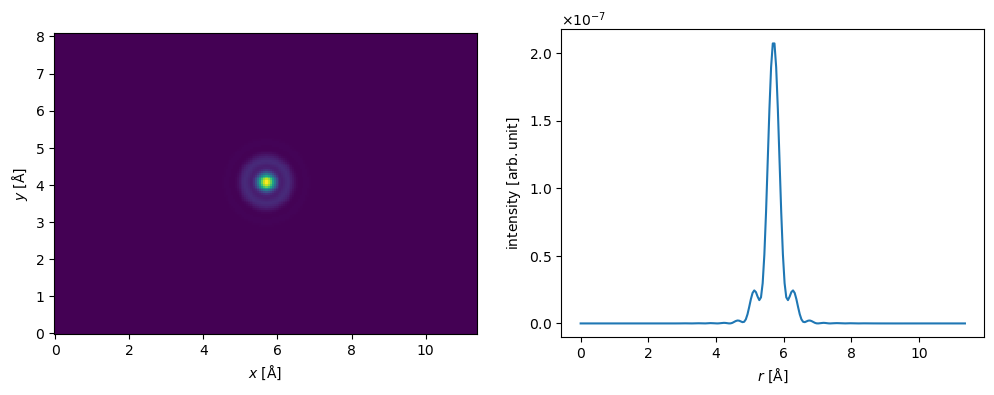

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

We select a scan region using fractional coordinates. We scan at the Nyquist frequency, allowing us to interpolate the measurements below.

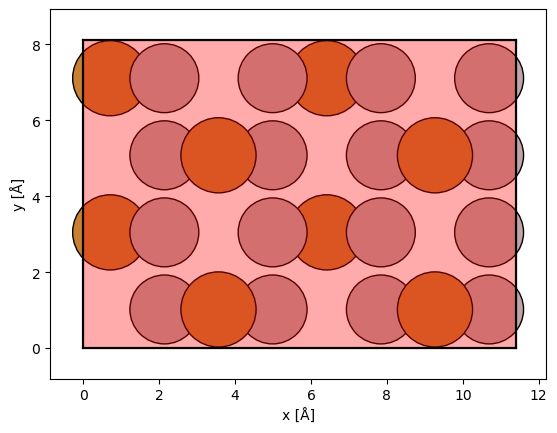

In [10]:
grid_scan = abtem.GridScan(
    start=(0, 0),
    end=(1,1),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential,
)

fig, ax = abtem.show_atoms(atoms)

grid_scan.add_to_plot(ax)

## Scan and detect

We use a flexible annular detector, this will let us choose the detector angles after the running multislice.

In [11]:
detector = abtem.FlexibleAnnularDetector()

We run the scanned multislice algorithm. See our [walkthrough on scanning and detecting](walkthrough:scan_and_detect).

In [12]:
flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)

flexible_measurement.compute()

[########################################] | 100% Completed | 6.65 ss


## Integrate measurements

The measurements are integrated to obtain the bright field, medium-angle annular dark field and high-angle annular dark field signals.

In [22]:
bf_measurement = flexible_measurement.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = flexible_measurement.integrate_radial(20, 131)
#haadf_measurement = flexible_measurement.integrate_radial(90, 200)

/home/chenguisen/miniconda3/envs/py4dstem/lib/python3.12/site-packages/abtem/measurements.py:432: SyntaxWarning: invalid escape sequence '\%'
  difference.metadata["tex_units"] = "$\%$"


RuntimeError: Integration limit exceeded.

In [18]:
maadf_measurement.shape

(58, 42)

In [23]:
flexible_measurement.shape[-2]

130

The measurements are stacked and shown as an exploded plot.

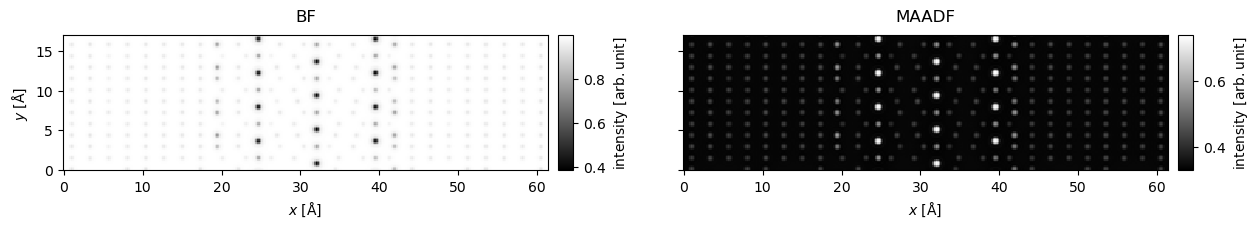

In [235]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement], ("BF", "MAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

## Postprocessing

Typically some post-processing steps are necessary to obtain the final results, see our [walkthrough on scanning and detecting](walkthrough:scan_and_detect) for more details

The measurements are interpolated to a sampling rate of $0.05 \ \mathrm{Å / pixel}$.

In [112]:
interpolated_measurements = measurements.interpolate(0.01)

In [149]:
interpolated_measurements = measurements.tile((3,1))


We can simulate partial spatial coherence by applying a gaussian filter. The standard deviation of the filter is $0.3 \ \mathrm{Å}$, the approximate size of the electron source.

In [150]:
filtered_measurements = interpolated_measurements.gaussian_filter(0.8)

The interpolated and filtered measurements shown as an exploded plot.

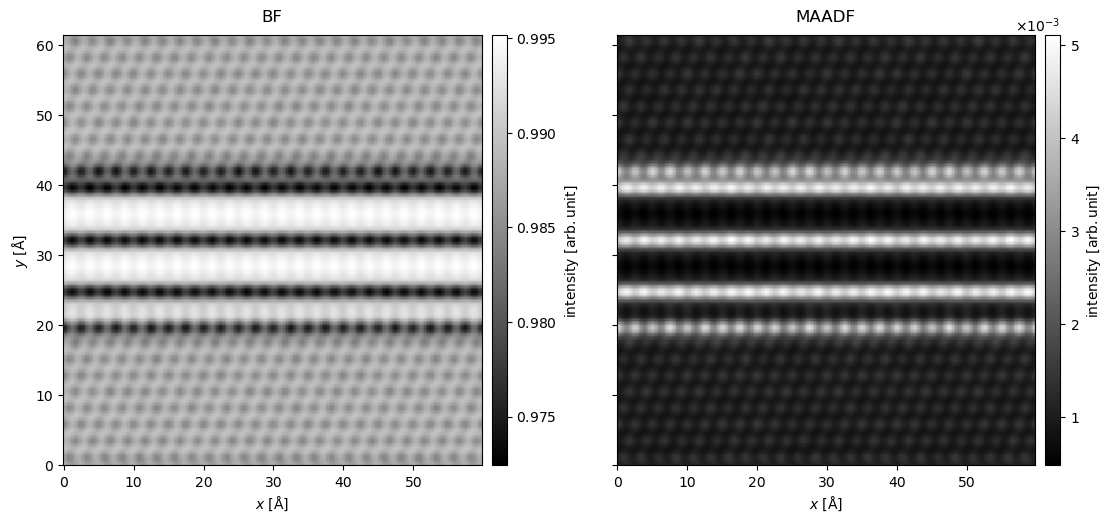

In [151]:
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

We simulate a finite electron dose of $10^7 \ \mathrm{e}^- / \mathrm{Å}^2$ by applying poisson noise

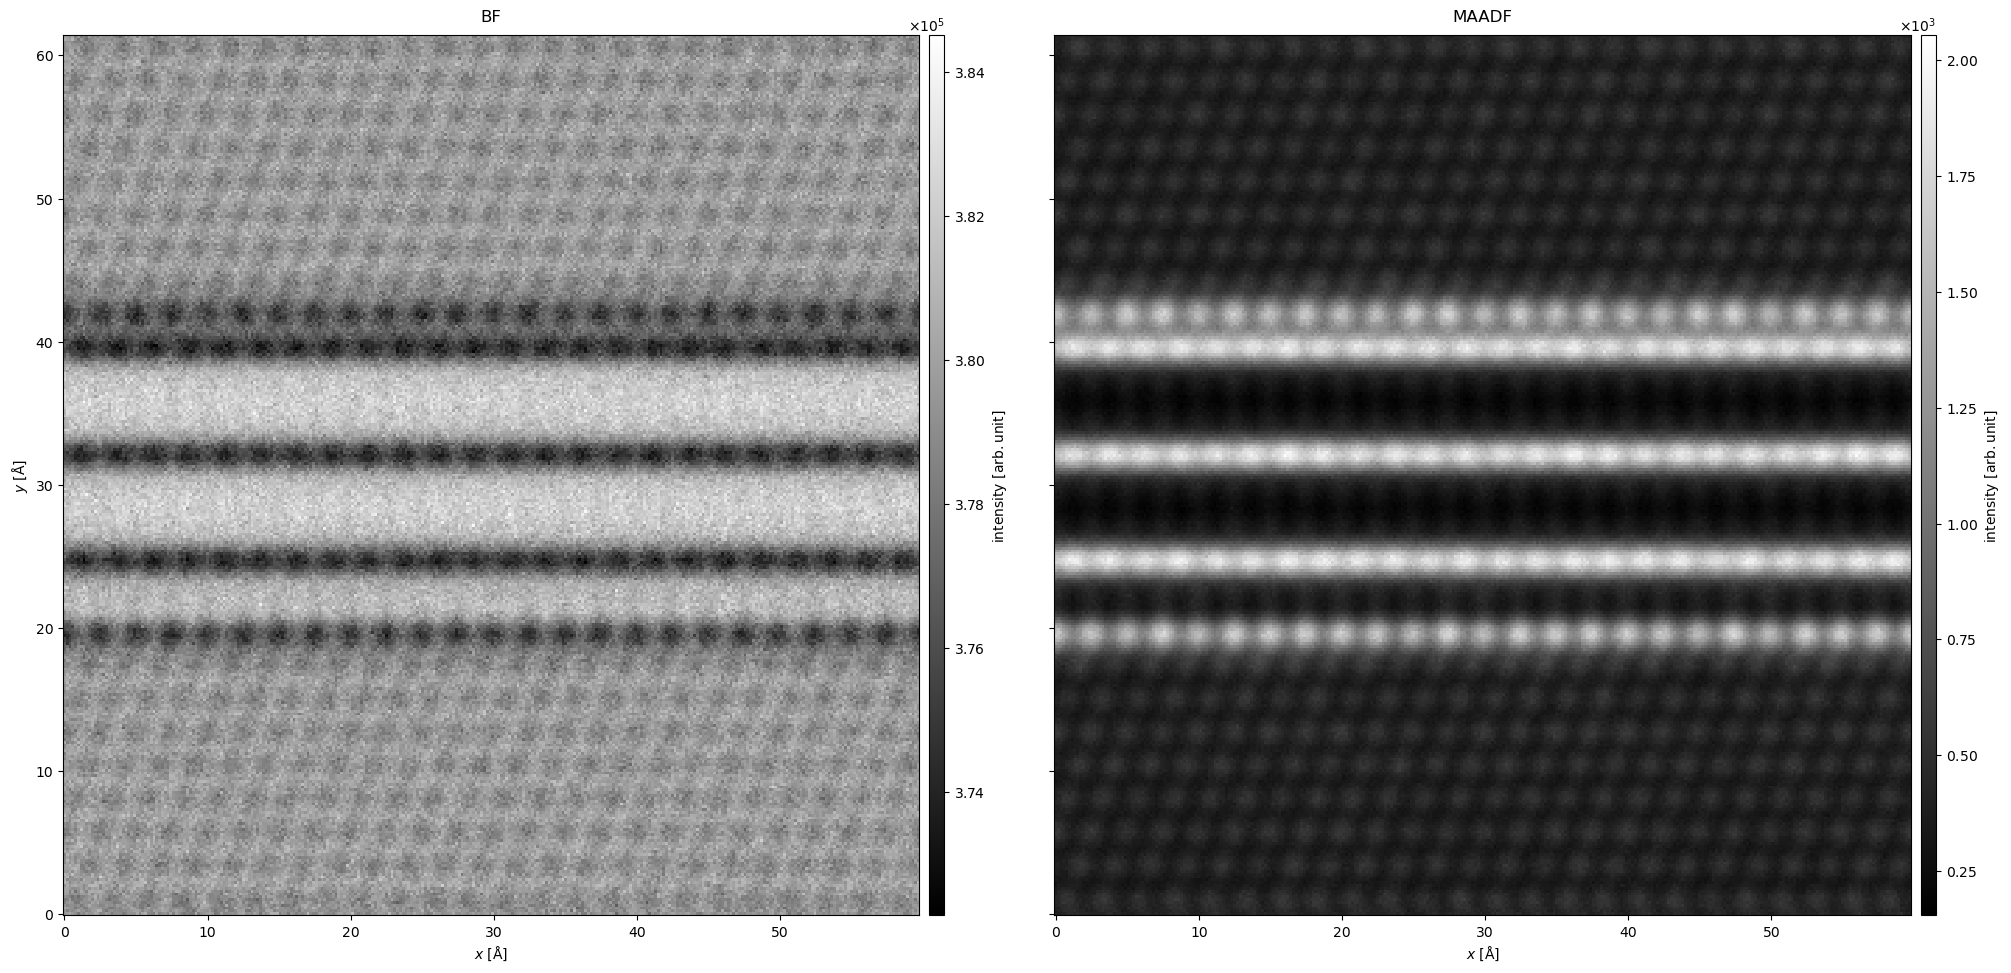

In [155]:
noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=1e7)

noisy_measurements.show(
    explode=True,
    figsize=(50, 10),
    cbar=True,
    cmap="gray",
);

Showing the results as a line profile often provides a better sense of relative intensities. 

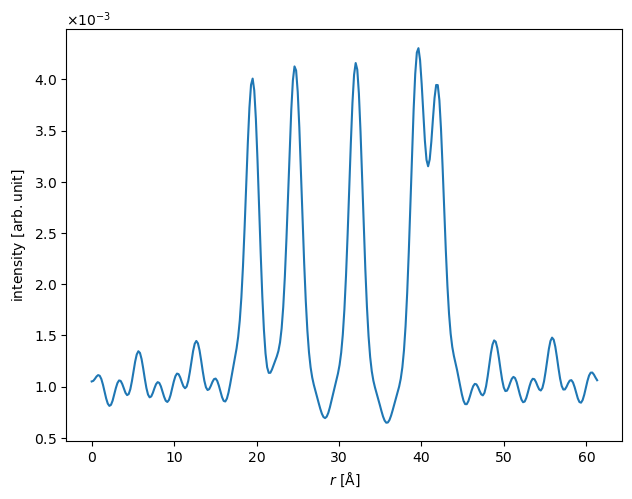

In [156]:
line_profile = filtered_measurements.interpolate_line(
    start=(1 / 2, 0), end=(1 / 2, 1), fractional=True
)

line_profile[-1].show();

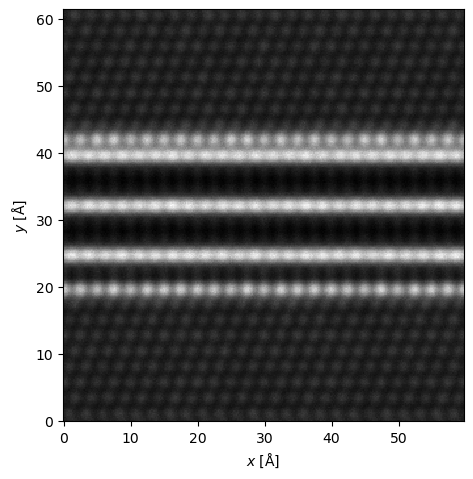

In [164]:
visualization = noisy_measurements[1].show(cmap="gray")
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches="tight", pad_inches=0, dpi=300)


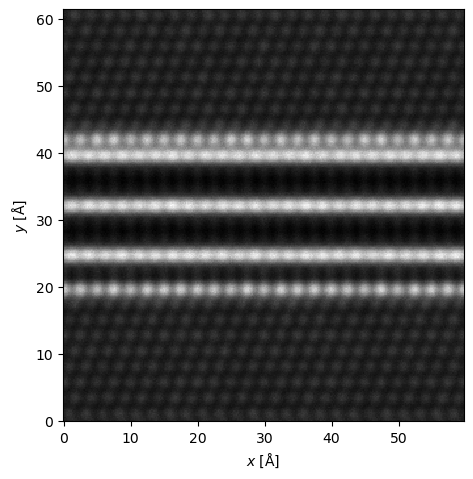

In [180]:
fig, ax = plt.subplots(figsize=(8, 8))
noisy_measurements[1].show(ax=ax, cmap="gray")
ax.axis('off')  # 隐藏坐标轴和刻度
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches='tight', pad_inches=0, dpi=300)
plt.close()  # 关闭图形释放内存
visualization = noisy_measurements[1].show(cmap="gray")


In [ ]:
import matplotlib.pyplot as plt
from ase.build import graphene
from ase.io import write
import ase
import abtem

(examples:stem_quickstart)=
# STEM quickstart

This notebook demonstrates a basic simulation of a scanning transmission electron microscopy image of graphene with a silicon dopant.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [ ]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model
We create an orthogonal graphene cell. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

In [135]:
#atoms = abtem.orthogonalize_cell(graphene(vacuum=2))
cif = "/home/chenguisen/cgs/group/yuanxin/10-layer StruRel.cif"
atoms = ase.io.read(cif)
atoms = atoms * (1, 1, 1)

/home/chenguisen/miniconda3/envs/py4dstem/lib/python3.12/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(1, setting=1). This may result in wrong setting!
  warnings.warn(


We dope the graphene with silicon by changing the atomic number of one of the atoms.

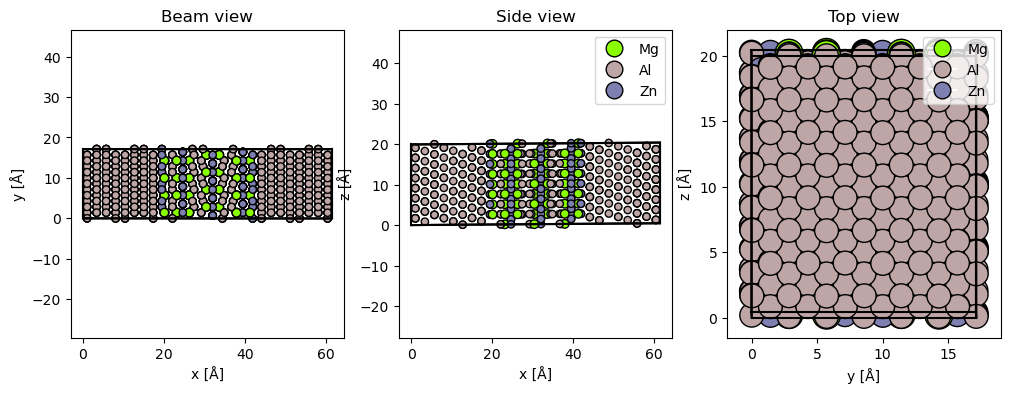

In [181]:
#atoms.numbers[17] = 14
desired_rotation = 90
rotate_atoms = atoms.copy()
rotate_atoms.rotate(desired_rotation, "x", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
abtem.show_atoms(rotate_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(rotate_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax3, plane="yz", title="Top view", legend=True);


In [182]:
atoms = rotate_atoms

## Potential

We create an ensemble of potentials using the frozen phonon model. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [183]:
frozen_phonons = abtem.FrozenPhonons(atoms, 8, sigmas=0.1)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [184]:
potential = abtem.Potential(frozen_phonons, sampling=0.05)

## Wave function

We create a probe wave function at an energy of $80 \ \mathrm{keV}$, an objective aperture of $30 \ \mathrm{mrad}$, a spherical aberration of $10 \ \mu\mathrm{m}$ and Scherzer defocus. See our [walkthrough on wave functions](walkthrough:wave_functions).

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence). 

In [1]:
probe = abtem.Probe(energy=300e3, semiangle_cutoff=25, Cs=10e4, defocus="scherzer")
probe.grid.match(potential)

print(f"defocus = {probe.aberrations.defocus} Å")
print(f"FWHM = {probe.profiles().width().compute()} Å")

NameError: name 'abtem' is not defined

We show the profile of the probe.

[                                        ] | 0% Completed | 163.13 us

[########################################] | 100% Completed | 101.12 ms
[########################################] | 100% Completed | 101.30 ms


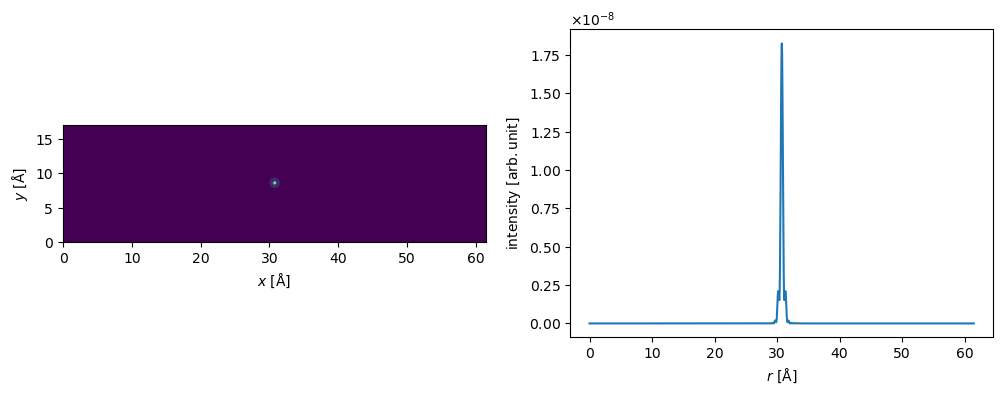

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

We select a scan region using fractional coordinates. We scan at the Nyquist frequency, allowing us to interpolate the measurements below.

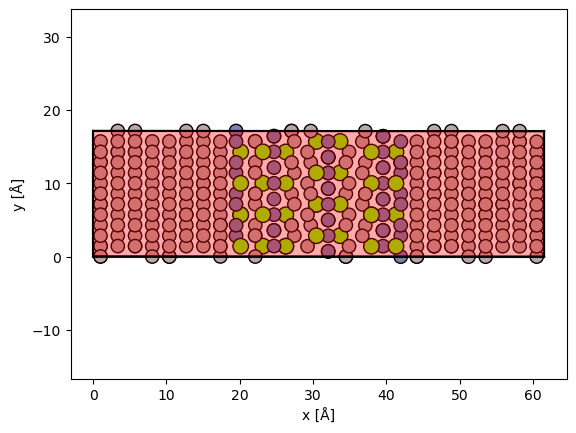

In [187]:
grid_scan = abtem.GridScan(
    start=(0, 0),
    end=(1,1),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential,
)

fig, ax = abtem.show_atoms(atoms)

grid_scan.add_to_plot(ax)

## Scan and detect

We use a flexible annular detector, this will let us choose the detector angles after the running multislice.

In [188]:
detector = abtem.FlexibleAnnularDetector()

We run the scanned multislice algorithm. See our [walkthrough on scanning and detecting](walkthrough:scan_and_detect).

In [189]:
flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)

flexible_measurement.compute()

[########################################] | 100% Completed | 25m 3ss


## Integrate measurements

The measurements are integrated to obtain the bright field, medium-angle annular dark field and high-angle annular dark field signals.

In [226]:
bf_measurement = flexible_measurement.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = flexible_measurement.integrate_radial(20, 50)
#haadf_measurement = flexible_measurement.integrate_radial(90, 200)

The measurements are stacked and shown as an exploded plot.

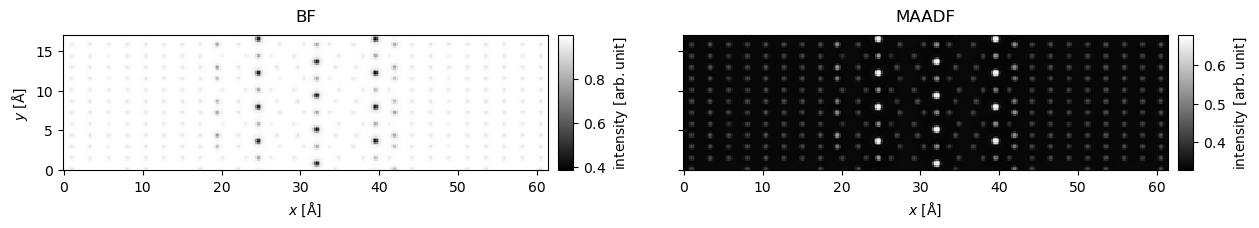

In [227]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement], ("BF", "MAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

## Postprocessing

Typically some post-processing steps are necessary to obtain the final results, see our [walkthrough on scanning and detecting](walkthrough:scan_and_detect) for more details

The measurements are interpolated to a sampling rate of $0.05 \ \mathrm{Å / pixel}$.

In [274]:
interpolated_measurements = measurements.interpolate(0.01)

In [ ]:
#interpolated_measurements = measurements.tile((1,3))


We can simulate partial spatial coherence by applying a gaussian filter. The standard deviation of the filter is $0.3 \ \mathrm{Å}$, the approximate size of the electron source.

In [288]:
filtered_measurements = interpolated_measurements.gaussian_filter(0.4)

The interpolated and filtered measurements shown as an exploded plot.

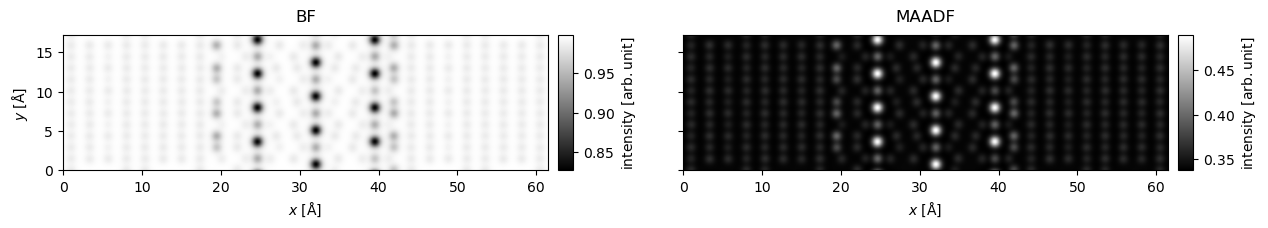

In [289]:
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

We simulate a finite electron dose of $10^7 \ \mathrm{e}^- / \mathrm{Å}^2$ by applying poisson noise

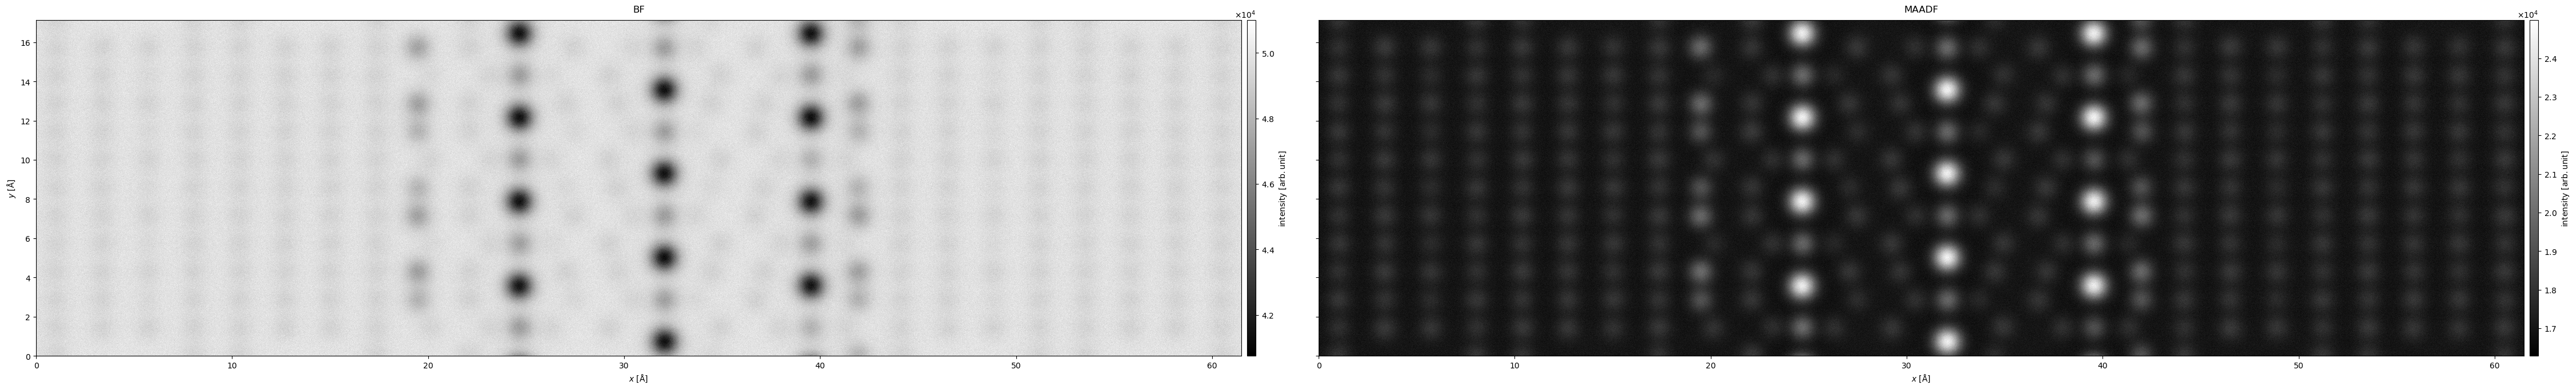

In [296]:
noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=5e8)

noisy_measurements.show(
    explode=True,
    figsize=(50, 10),
    cbar=True,
    cmap="gray",
);

Showing the results as a line profile often provides a better sense of relative intensities. 

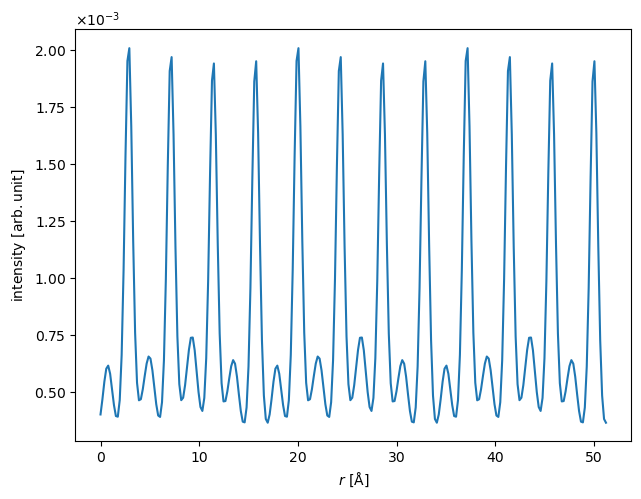

In [211]:
line_profile = filtered_measurements.interpolate_line(
    start=(1 / 2, 0), end=(1 / 2, 1), fractional=True
)

line_profile[-1].show();

AttributeError: 'Visualization' object has no attribute 'axis_off'

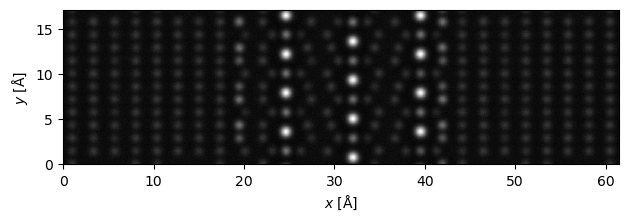

In [269]:
visualization = noisy_measurements[1].show(cmap="gray")
visualization.axis_off()
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches="tight", pad_inches=0, dpi=300)


In [297]:
fig, ax = plt.subplots(figsize=(8, 8))
noisy_measurements[1].show(ax=ax, cmap="gray")
ax.axis('off')  # 隐藏坐标轴和刻度
plt.tight_layout()  # 自动调整布局，防止图形超出边界
plt.savefig("../thumbnails/stem_quickstart_1.png", bbox_inches='tight', pad_inches=0, dpi=200)
plt.close()  # 关闭图形释放内存
